In [1]:
# =========================
# 0. Imports
# =========================
import math
from functools import partial
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

key = jax.random.PRNGKey(0)

In [2]:
# =========================
# 1. Toy 2D samplers
# =========================
def sample_gaussian(key, n, mean=(0.0, 0.0), scale=1.0):
    mean = jnp.array(mean)
    x = jax.random.normal(key, (n, 2))
    return mean + scale * x

def sample_8gaussians(key, n, radius=5.0, std=0.4):
    centers = jnp.array([
        [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0],
        [1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)],
        [1.0 / jnp.sqrt(2), -1.0 / jnp.sqrt(2)],
        [-1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)],
        [-1.0 / jnp.sqrt(2), -1.0 / jnp.sqrt(2)],
    ]) * radius
    k1, k2 = jax.random.split(key)
    idx = jax.random.randint(k1, (n,), 0, 8)
    noise = std * jax.random.normal(k2, (n, 2))
    return centers[idx] + noise

def sample_moons(key, n, noise=0.08):
    n1 = n // 2
    n2 = n - n1
    k1, k2, k3 = jax.random.split(key, 3)

    t1 = jax.random.uniform(k1, (n1,), minval=0.0, maxval=jnp.pi)
    moon1 = jnp.stack([jnp.cos(t1), jnp.sin(t1)], axis=1)

    t2 = jax.random.uniform(k2, (n2,), minval=0.0, maxval=jnp.pi)
    moon2 = jnp.stack([1.0 - jnp.cos(t2), 1.0 - jnp.sin(t2) - 0.5], axis=1)

    x = jnp.concatenate([moon1, moon2], axis=0)
    x = x + noise * jax.random.normal(k3, x.shape)
    return 3.0 * x

In [3]:
# =========================
# 2. Pairing functions
# =========================
def independent_pairing(x0, x1):
    # Just pair by index after independent sampling
    return x0, x1

def sinkhorn_coupling(x0, x1, epsilon=0.1):
    geom = pointcloud.PointCloud(x0, x1, epsilon=epsilon)
    prob = linear_problem.LinearProblem(geom)
    solver = sinkhorn.Sinkhorn()
    out = solver(prob)
    # transport matrix
    P = out.matrix
    return P, out

def sample_pairs_from_coupling(key, x0, x1, P):
    row_sums = jnp.sum(P, axis=1, keepdims=True) + 1e-12
    probs = P / row_sums

    n = x0.shape[0]
    keys = jax.random.split(key, n)

    sampled_indices = jnp.array([
        jax.random.choice(keys[i], x1.shape[0], p=probs[i])
        for i in range(n)
    ])

    paired_x1 = x1[sampled_indices]
    return x0, paired_x1

def hungarian_pairing(x0, x1):
    # Exact linear assignment on squared Euclidean cost
    C = jnp.sum((x0[:, None, :] - x1[None, :, :]) ** 2, axis=-1)  # (n, n)
    _, col_ind = linear_sum_assignment(np.asarray(C))
    return x0, x1[jnp.array(col_ind)]

def sinkhorn_barycentric_pairing(x0, x1, P):
    # Barycentric target y_i = sum_j P_ij x1_j / sum_j P_ij
    row_sums = jnp.sum(P, axis=1, keepdims=True) + 1e-12
    W = P / row_sums
    x1_bar = W @ x1
    return x0, x1_bar

In [4]:
# =========================
# 3. Simple MLP in raw JAX
# =========================
def init_mlp_params(key, widths):
    params = []
    keys = jax.random.split(key, len(widths) - 1)
    for k, (din, dout) in zip(keys, zip(widths[:-1], widths[1:])):
        w_key, _ = jax.random.split(k)
        W = 0.1 * jax.random.normal(w_key, (din, dout))
        b = jnp.zeros((dout,))
        params.append((W, b))
    return params

def mlp_apply(params, x):
    h = x
    for i, (W, b) in enumerate(params):
        h = h @ W + b
        if i < len(params) - 1:
            h = jax.nn.silu(h)
    return h

def vf_apply(params, x, t):
    # x: (batch, 2), t: (batch, 1)
    inp = jnp.concatenate([x, t], axis=1)  # shape (batch, 3)
    return mlp_apply(params, inp)          # shape (batch, 2)

In [5]:
# =========================
# 4. Flow-matching loss
# =========================
def fm_loss(params, x0, x1, t):
    # linear interpolation path
    xt = (1.0 - t) * x0 + t * x1
    target_v = x1 - x0
    pred_v = vf_apply(params, xt, t)
    return jnp.mean(jnp.sum((pred_v - target_v) ** 2, axis=1))

In [6]:
# =========================
# 5. Training step
# =========================
optimizer = optax.adam(1e-3)

@jax.jit
def train_step(params, opt_state, x0, x1, t):
    loss, grads = jax.value_and_grad(fm_loss)(params, x0, x1, t)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

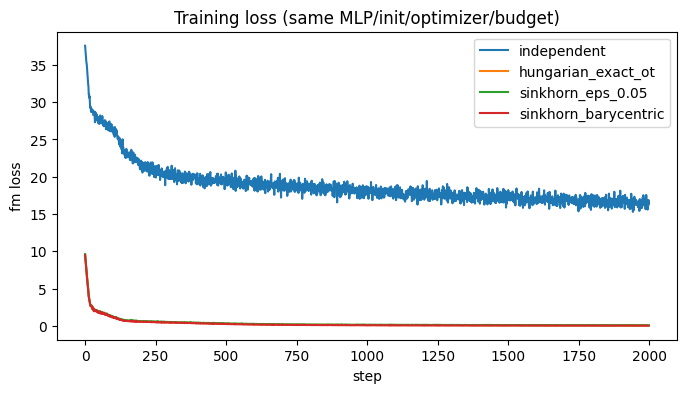

In [7]:
# =========================
# 6. Unified setup + training (4 couplings)
# =========================
n = 1000
eps = 0.05
train_steps = 2000
rollout_steps = 32
widths = [3, 128, 128, 128, 2]

# Data + keys
key, k0, k1, kpair, kinit = jax.random.split(key, 5)
x0 = sample_moons(k0, n)
x1 = sample_8gaussians(k1, n)

# Couplings
x0_ind, x1_ind = independent_pairing(x0, x1)

x0_hun, x1_hun = hungarian_pairing(x0, x1)

P, out = sinkhorn_coupling(x0, x1, epsilon=eps)
x0_sink, x1_sink = sample_pairs_from_coupling(kpair, x0, x1, P)

x0_bar, x1_bar = sinkhorn_barycentric_pairing(x0, x1, P)

# Same rollout solver for all
def rollout_euler(params, x_init, steps=32):
    dt = 1.0 / steps
    x = x_init
    traj = [x]
    for k in range(steps):
        tval = jnp.full((x.shape[0], 1), k / steps)
        v = vf_apply(params, x, tval)
        x = x + dt * v
        traj.append(x)
    return traj

# Same init for all experiments
base_params = init_mlp_params(kinit, widths)

def make_t_schedule(seed, steps, n):
    k = jax.random.PRNGKey(seed)
    keys = jax.random.split(k, steps)
    return [jax.random.uniform(ki, (n, 1)) for ki in keys]

t_schedule = make_t_schedule(seed=123, steps=train_steps, n=n)

def train_on_fixed_pairs(params0, x0_pair, x1_pair, t_schedule):
    params = params0
    opt_state = optimizer.init(params)
    losses = []
    for t in t_schedule:
        params, opt_state, loss = train_step(params, opt_state, x0_pair, x1_pair, t)
        losses.append(float(loss))
    return params, np.array(losses)

couplings = {
    "independent": (x0_ind, x1_ind),
    "hungarian_exact_ot": (x0_hun, x1_hun),
    f"sinkhorn_eps_{eps}": (x0_sink, x1_sink),
    "sinkhorn_barycentric": (x0_bar, x1_bar),
}

results = {}
for name, (xa, xb) in couplings.items():
    params_tr, losses = train_on_fixed_pairs(base_params, xa, xb, t_schedule)
    traj = rollout_euler(params_tr, x0[:200], steps=rollout_steps)
    results[name] = {"params": params_tr, "losses": losses, "traj": traj}

# Loss curves
plt.figure(figsize=(8, 4))
for name, r in results.items():
    plt.plot(r["losses"], label=name)
plt.title("Training loss (same MLP/init/optimizer/budget)")
plt.xlabel("step")
plt.ylabel("fm loss")
plt.legend()
plt.show()


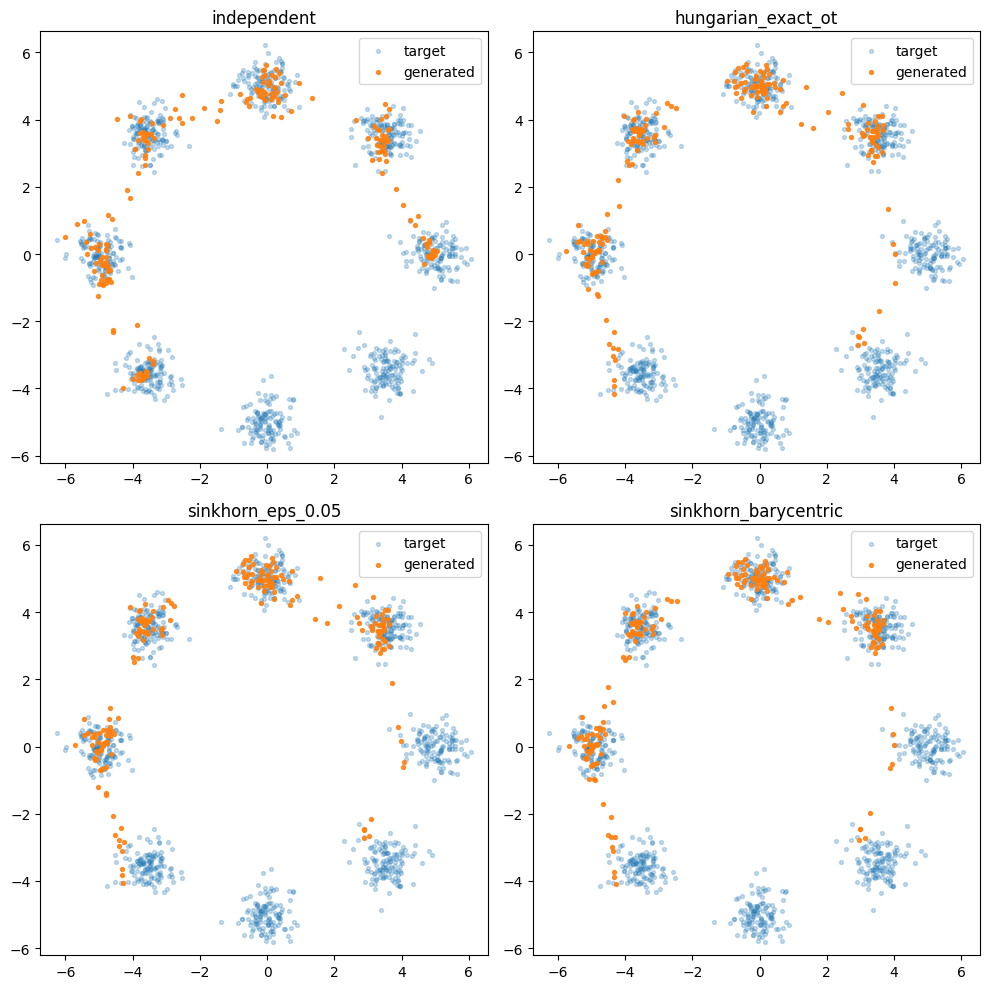

In [8]:
# =========================
# 7. Final generated samples per coupling
# =========================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    gen = r["traj"][-1]
    ax.scatter(x1[:, 0], x1[:, 1], s=8, alpha=0.25, label="target")
    ax.scatter(gen[:, 0], gen[:, 1], s=8, alpha=0.85, label="generated")
    ax.set_title(name)
    ax.axis("equal")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


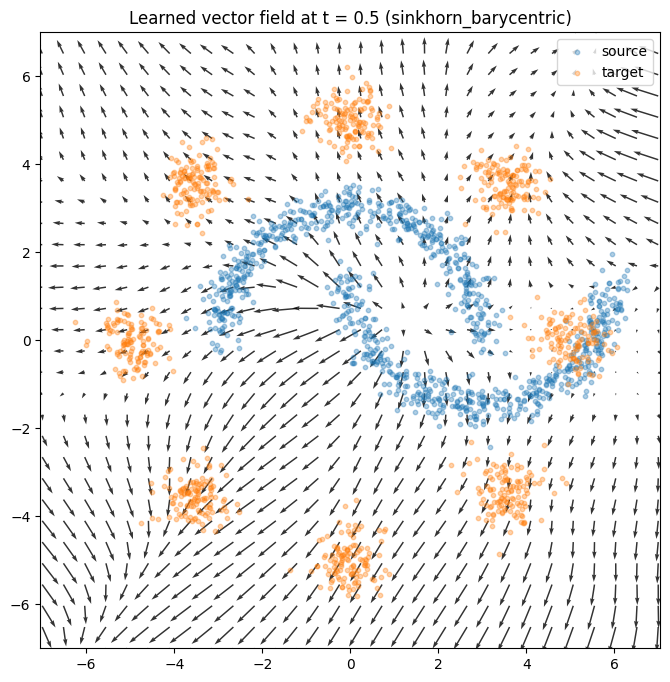

In [9]:
# =========================
# 8. Vector field at t=0.5 for one selected coupling
# =========================
selected_name = "sinkhorn_barycentric"  # change if you want another one
params_sel = results[selected_name]["params"]

grid_x = jnp.linspace(-7, 7, 30)
grid_y = jnp.linspace(-7, 7, 30)
xx, yy = jnp.meshgrid(grid_x, grid_y)
points = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

t = 0.5 * jnp.ones((points.shape[0], 1))
v = vf_apply(params_sel, points, t)

u = np.array(v[:, 0]).reshape(xx.shape)
w = np.array(v[:, 1]).reshape(yy.shape)

plt.figure(figsize=(8, 8))
plt.quiver(np.array(xx), np.array(yy), u, w, angles="xy", scale_units="xy", scale=10, alpha=0.8)
plt.scatter(np.array(x0[:, 0]), np.array(x0[:, 1]), s=10, alpha=0.35, label="source")
plt.scatter(np.array(x1[:, 0]), np.array(x1[:, 1]), s=10, alpha=0.35, label="target")
plt.title(f"Learned vector field at t = 0.5 ({selected_name})")
plt.legend()
plt.axis("equal")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.show()


=== Summary metrics per coupling ===


,coupling,PE,NPE,W2_data_sq,endpoint_W2_sq_at_32,loss_mean,loss_var,target_velocity_kernel_var
0,hungarian_exact_ot,9.317200,0.015988,9.468581,0.124501,0.327948,0.477760,0.463889
1,independent,20.028852,1.115296,9.468581,0.942006,18.893074,8.313301,27.746258
2,sinkhorn_barycentric,9.249064,0.023184,9.468581,0.087304,0.297776,0.468413,0.441822
3,sinkhorn_eps_0.05,9.240755,0.024061,9.468581,0.144087,0.364367,0.474026,0.528094



=== Low-NFE endpoint W2^2 (head) ===


,coupling,nfe,endpoint_w2_sq
0,independent,4,2.363996
1,independent,8,1.454938
2,independent,16,1.122773
3,independent,32,0.942006
4,independent,64,0.853649


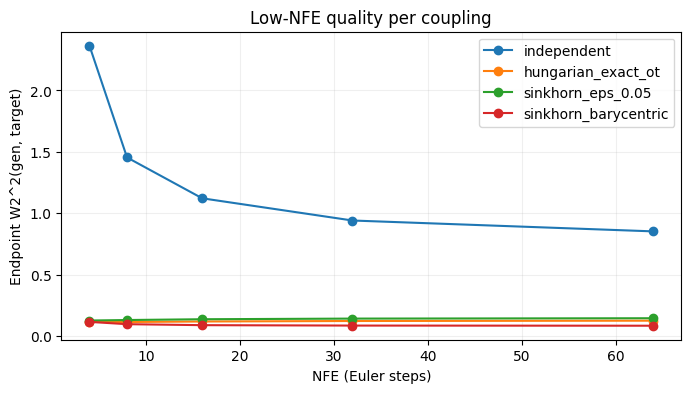

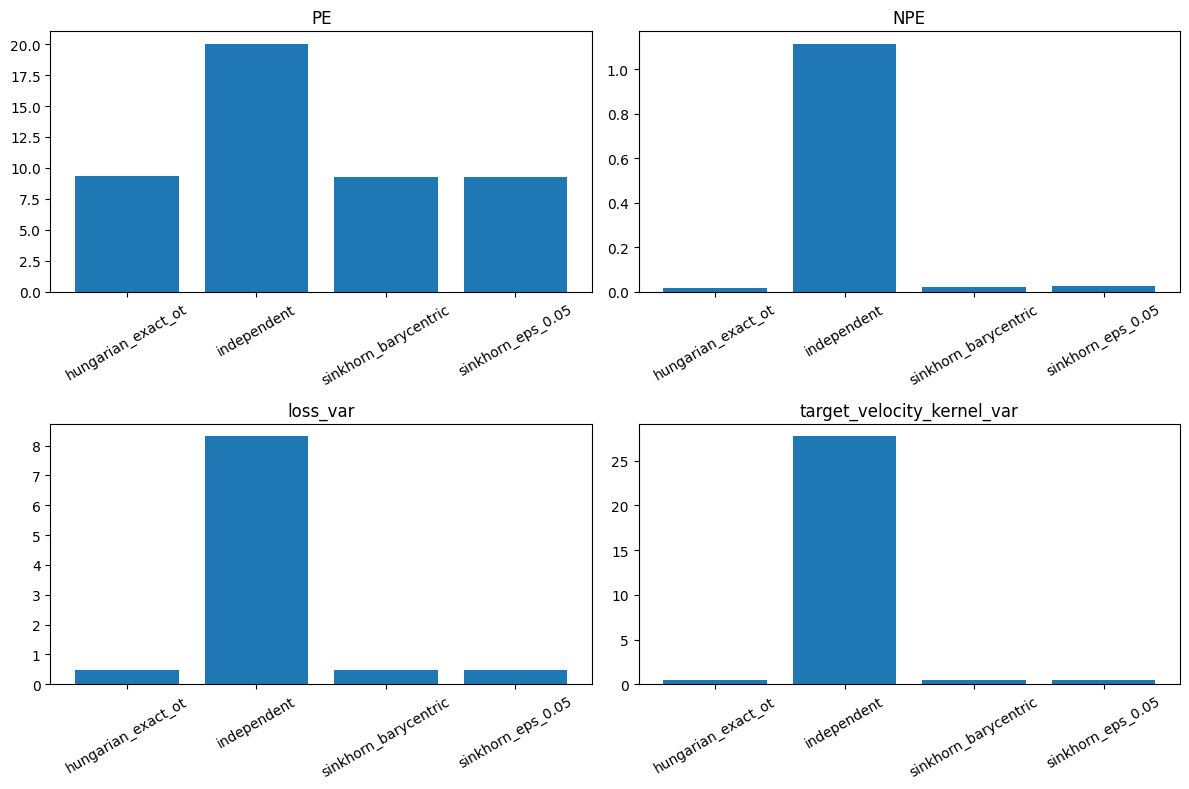

In [10]:
# =========================
# 9. Metrics for each coupling: PE, endpoint W2^2, low-NFE, training proxies
# =========================

# ---------- helpers ----------
def empirical_w2_squared_hungarian(A, B):
    """
    A, B: (n, d), equal n
    Returns average squared matching cost.
    """
    C = jnp.sum((A[:, None, :] - B[None, :, :]) ** 2, axis=-1)  # (n,n)
    row_ind, col_ind = linear_sum_assignment(np.asarray(C))
    return float(np.asarray(C)[row_ind, col_ind].mean())

def rollout_euler_final(params, x_init, steps):
    dt = 1.0 / steps
    x = x_init
    for k in range(steps):
        tval = jnp.full((x.shape[0], 1), k / steps)
        v = vf_apply(params, x, tval)
        x = x + dt * v
    return x

def path_energy(params, x_init, steps=256):
    """
    PE = E \int_0^1 ||v(x_t,t)||^2 dt
    estimated by Euler quadrature along rollout trajectories.
    """
    dt = 1.0 / steps
    x = x_init
    acc = 0.0
    for k in range(steps):
        tval = jnp.full((x.shape[0], 1), k / steps)
        v = vf_apply(params, x, tval)
        acc += float(jnp.mean(jnp.sum(v * v, axis=1))) * dt
        x = x + dt * v
    return acc

def velocity_variance_kernel(
    xa,
    xb,
    n_time_samples=8,
    sigma=0.5,
    key=jax.random.PRNGKey(0),
    n_query=1024,
    n_ref=2048,
    include_time=False,
    time_scale=1.0,
):
    """
    Estimate E[ Var(v | x_t) ] using kernel conditional moments.
    Uses subsampling for CPU-friendly runtime.
    """
    N, d = xa.shape
    vel0 = xb - xa  # (N, d)

    key_t, key_q, key_r = jax.random.split(key, 3)
    t = jax.random.uniform(key_t, (n_time_samples, N, 1))  # (T,N,1)

    xt = (1.0 - t) * xa[None, :, :] + t * xb[None, :, :]   # (T,N,d)
    vel = jnp.broadcast_to(vel0[None, :, :], (n_time_samples, N, d))  # (T,N,d)

    xt = xt.reshape(-1, d)
    vel = vel.reshape(-1, d)
    t_flat = t.reshape(-1, 1)
    M = xt.shape[0]

    feat = jnp.concatenate([xt, time_scale * t_flat], axis=1) if include_time else xt

    nq = int(min(n_query, M))
    nr = int(min(n_ref, M))

    q_idx = jax.random.choice(key_q, M, shape=(nq,), replace=False)
    r_idx = jax.random.choice(key_r, M, shape=(nr,), replace=False)

    fq = feat[q_idx]      # (nq, fdim)
    fr = feat[r_idx]      # (nr, fdim)
    v_ref = vel[r_idx]    # (nr, d)

    diff = fq[:, None, :] - fr[None, :, :]
    dist2 = jnp.sum(diff**2, axis=-1)

    K = jnp.exp(-dist2 / (2.0 * sigma**2))
    K = K / (jnp.sum(K, axis=1, keepdims=True) + 1e-8)

    mean_v = K @ v_ref
    mean_v2 = K @ (v_ref**2)

    var = jnp.maximum(mean_v2 - mean_v**2, 0.0)
    local_var = jnp.sum(var, axis=1)

    return jnp.mean(local_var)

# ---------- constants ----------
n_eval = min(x0.shape[0], x1.shape[0])   # keep equal size
x0_eval = x0[:n_eval]
x1_eval = x1[:n_eval]

# W2^2(mu0, mu1) baseline for NPE
w2_data = empirical_w2_squared_hungarian(x0_eval, x1_eval)

nfe_list = [4, 8, 16, 32, 64]

# ---------- per-coupling metrics ----------
summary_rows = []
low_nfe_rows = []

for name, r in results.items():
    params = r["params"]
    losses = np.asarray(r["losses"])

    # (1) Path energy + NPE
    pe = path_energy(params, x0_eval, steps=256)
    npe = abs(pe - w2_data) / (w2_data + 1e-12)

    # (2) Endpoint transport error at default rollout budget
    x_gen_32 = rollout_euler_final(params, x0_eval, steps=32)
    w2_endpoint_32 = empirical_w2_squared_hungarian(x_gen_32, x1_eval)

    # (3) Low-NFE quality: endpoint W2^2 vs NFE
    for nfe in nfe_list:
        x_gen = rollout_euler_final(params, x0_eval, steps=nfe)
        w2_ep = empirical_w2_squared_hungarian(x_gen, x1_eval)
        low_nfe_rows.append({"coupling": name, "nfe": nfe, "endpoint_w2_sq": w2_ep})

    # (4) Training difficulty proxies
    loss_var = float(np.var(losses))
    xa, xb = couplings[name]

    key, kv = jax.random.split(key)
    target_velocity_kernel_var = float(
        velocity_variance_kernel(
            xa, xb,
            n_time_samples=8,
            sigma=0.6,
            key=kv,
            n_query=1024,
            n_ref=2048,
            include_time=True,
            time_scale=1.0,
        )
    )

    summary_rows.append({
        "coupling": name,
        "PE": pe,
        "NPE": npe,
        "W2_data_sq": w2_data,
        "endpoint_W2_sq_at_32": w2_endpoint_32,
        "loss_mean": float(np.mean(losses)),
        "loss_var": loss_var,
        "target_velocity_kernel_var": target_velocity_kernel_var,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("coupling").reset_index(drop=True)
low_nfe_df = pd.DataFrame(low_nfe_rows)

print("=== Summary metrics per coupling ===")
display(summary_df)

print("\n=== Low-NFE endpoint W2^2 (head) ===")
display(low_nfe_df.head())

# ---------- plots ----------
# low-NFE curves
plt.figure(figsize=(8, 4))
for name in low_nfe_df["coupling"].unique():
    d = low_nfe_df[low_nfe_df["coupling"] == name].sort_values("nfe")
    plt.plot(d["nfe"], d["endpoint_w2_sq"], marker="o", label=name)
plt.xlabel("NFE (Euler steps)")
plt.ylabel("Endpoint W2^2(gen, target)")
plt.title("Low-NFE quality per coupling")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# summary bar plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics_to_plot = ["PE", "NPE", "loss_var", "target_velocity_kernel_var"]
for ax, m in zip(axes.ravel(), metrics_to_plot):
    ax.bar(summary_df["coupling"], summary_df[m])
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


=== Trajectory curvature metrics ===


,coupling,vel_diff_sq,ang_dev
0,hungarian_exact_ot,0.000077,0.000004
1,independent,0.014727,0.002089
2,sinkhorn_barycentric,0.000064,0.000005
3,sinkhorn_eps_0.05,0.000080,0.000004


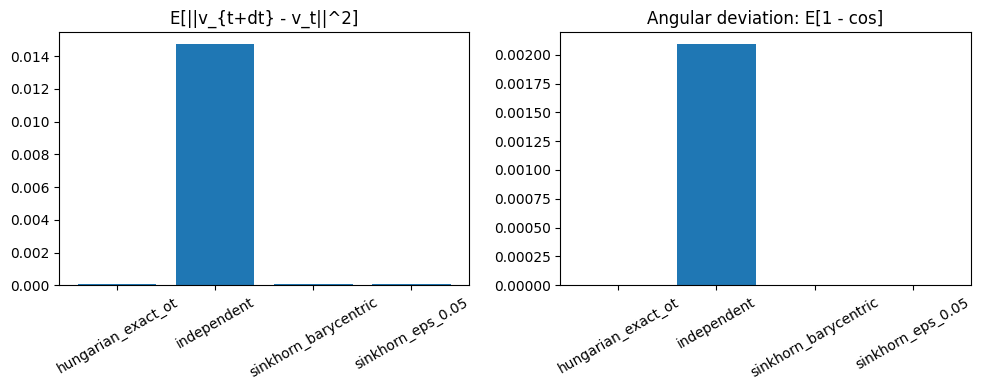

In [11]:
# =========================
# 10. Trajectory curvature / angular deviation (per coupling)
# =========================

def trajectory_curvature_metrics(params, x_init, steps=128, eps=1e-8):
    """
    Computes two curvature-style metrics along Euler trajectories:
    1) vel_diff_sq: E[ ||v_{t+dt} - v_t||^2 ]
    2) ang_dev:     E[ 1 - cos(v_{t+dt}, v_t) ]  (0 = perfectly aligned)
    """
    dt = 1.0 / steps
    x = x_init

    vel_diffs = []
    ang_devs = []

    # first velocity
    t0 = jnp.zeros((x.shape[0], 1))
    v_prev = vf_apply(params, x, t0)

    for k in range(1, steps + 1):
        # advance state with previous velocity
        x = x + dt * v_prev

        tval = jnp.full((x.shape[0], 1), k / steps)
        v_curr = vf_apply(params, x, tval)

        # squared velocity increment
        dv2 = jnp.sum((v_curr - v_prev) ** 2, axis=1)
        vel_diffs.append(jnp.mean(dv2))

        # angular deviation = 1 - cosine similarity
        num = jnp.sum(v_curr * v_prev, axis=1)
        den = (jnp.linalg.norm(v_curr, axis=1) * jnp.linalg.norm(v_prev, axis=1) + eps)
        cos = jnp.clip(num / den, -1.0, 1.0)
        ang = 1.0 - cos
        ang_devs.append(jnp.mean(ang))

        v_prev = v_curr

    return {
        "vel_diff_sq": float(jnp.mean(jnp.stack(vel_diffs))),
        "ang_dev": float(jnp.mean(jnp.stack(ang_devs))),
    }

# evaluate on same source subset for fairness
x_curv = x0_eval  # from previous metrics cell

curv_rows = []
for name, r in results.items():
    m = trajectory_curvature_metrics(r["params"], x_curv, steps=128)
    curv_rows.append({"coupling": name, **m})

curv_df = pd.DataFrame(curv_rows).sort_values("coupling").reset_index(drop=True)
print("=== Trajectory curvature metrics ===")
display(curv_df)

# plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(curv_df["coupling"], curv_df["vel_diff_sq"])
axes[0].set_title("E[||v_{t+dt} - v_t||^2]")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(curv_df["coupling"], curv_df["ang_dev"])
axes[1].set_title("Angular deviation: E[1 - cos]")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [12]:
# =========================
# Multi-epsilon Sinkhorn experiments (sampled + barycentric)
# Reuses your existing train/eval functions:
# - train_on_fixed_pairs, rollout_euler, rollout_euler_final
# - path_energy, empirical_w2_squared_hungarian
# - velocity_variance_kernel, trajectory_curvature_metrics
# =========================

# ---- config ----
n = 1000
eps_list = [0.01, 0.03, 0.05, 0.1, 0.2]
train_steps = 2000
rollout_steps = 32
widths = [3, 128, 128, 128, 2]
nfe_list = [4, 8, 16, 32, 64]

# ---- data (same data for all eps for fair comparison) ----
key, k0, k1, kinit, kpair_master, keval_master = jax.random.split(key, 6)
x0 = sample_moons(k0, n)
x1 = sample_8gaussians(k1, n)

base_params = init_mlp_params(kinit, widths)
t_schedule = make_t_schedule(seed=123, steps=train_steps, n=n)

# ---- run training for each eps and each Sinkhorn mode ----
run_records = []
pair_keys = jax.random.split(kpair_master, len(eps_list))

for eps, kpair in zip(eps_list, pair_keys):
    P, out = sinkhorn_coupling(x0, x1, epsilon=eps)

    # plan-level stats (useful for epsilon-vs-entropy/sharpness plots)
    row_sums = jnp.sum(P, axis=1, keepdims=True) + 1e-12
    W = P / row_sums
    plan_entropy = float(-jnp.mean(jnp.sum(W * jnp.log(W + 1e-12), axis=1)))
    plan_sharpness = float(jnp.mean(jnp.max(W, axis=1)))
    C = jnp.sum((x0[:, None, :] - x1[None, :, :]) ** 2, axis=-1)
    plan_transport_cost = float(jnp.sum(P * C))

    couplings_eps = {
        "sinkhorn_sampled": sample_pairs_from_coupling(kpair, x0, x1, P),
        "sinkhorn_barycentric": sinkhorn_barycentric_pairing(x0, x1, P),
    }

    for mode, (xa, xb) in couplings_eps.items():
        params_tr, losses = train_on_fixed_pairs(base_params, xa, xb, t_schedule)
        traj = rollout_euler(params_tr, x0[:200], steps=rollout_steps)

        run_records.append({
            "eps": float(eps),
            "mode": mode,
            "params": params_tr,
            "losses": np.asarray(losses),
            "traj": traj,
            "xa": xa,
            "xb": xb,
            "P": P,
            "sinkhorn_out": out,
            "plan_entropy": plan_entropy,
            "plan_sharpness": plan_sharpness,
            "plan_transport_cost": plan_transport_cost,
        })

# ---- compute same metrics as before for every (eps, mode) ----
n_eval = min(x0.shape[0], x1.shape[0])
x0_eval = x0[:n_eval]
x1_eval = x1[:n_eval]
w2_data = empirical_w2_squared_hungarian(x0_eval, x1_eval)

summary_rows = []
low_nfe_rows = []

k_eval = keval_master
for rec in run_records:
    params = rec["params"]
    losses = rec["losses"]

    pe = path_energy(params, x0_eval, steps=256)
    npe = abs(pe - w2_data) / (w2_data + 1e-12)

    x_gen_32 = rollout_euler_final(params, x0_eval, steps=32)
    w2_endpoint_32 = empirical_w2_squared_hungarian(x_gen_32, x1_eval)

    for nfe in nfe_list:
        x_gen = rollout_euler_final(params, x0_eval, steps=nfe)
        w2_ep = empirical_w2_squared_hungarian(x_gen, x1_eval)
        low_nfe_rows.append({
            "eps": rec["eps"],
            "mode": rec["mode"],
            "nfe": nfe,
            "endpoint_w2_sq": w2_ep,
        })

    k_eval, kv = jax.random.split(k_eval)
    target_velocity_kernel_var = float(
        velocity_variance_kernel(
            rec["xa"], rec["xb"],
            n_time_samples=8,
            sigma=0.6,
            key=kv,
            n_query=1024,
            n_ref=2048,
            include_time=True,
            time_scale=1.0,
        )
    )

    curv = trajectory_curvature_metrics(params, x0_eval, steps=128)

    summary_rows.append({
        "eps": rec["eps"],
        "mode": rec["mode"],
        "PE": pe,
        "NPE": npe,
        "W2_data_sq": w2_data,
        "endpoint_W2_sq_at_32": w2_endpoint_32,
        "loss_mean": float(np.mean(losses)),
        "loss_var": float(np.var(losses)),
        "target_velocity_kernel_var": target_velocity_kernel_var,
        "vel_diff_sq": curv["vel_diff_sq"],
        "ang_dev": curv["ang_dev"],
        "plan_entropy": rec["plan_entropy"],
        "plan_sharpness": rec["plan_sharpness"],
        "plan_transport_cost": rec["plan_transport_cost"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["mode", "eps"]).reset_index(drop=True)
low_nfe_df = pd.DataFrame(low_nfe_rows).sort_values(["mode", "eps", "nfe"]).reset_index(drop=True)

display(summary_df.head())
display(low_nfe_df.head())


,eps,mode,PE,NPE,W2_data_sq,endpoint_W2_sq_at_32,loss_mean,loss_var,target_velocity_kernel_var,vel_diff_sq,ang_dev,plan_entropy,plan_sharpness,plan_transport_cost
0,0.01,sinkhorn_barycentric,8.217369,0.156827,9.745772,1.227224,0.272870,0.418151,0.444938,0.000081,0.000009,1.742553,0.358723,8.382029
1,0.03,sinkhorn_barycentric,9.253279,0.050534,9.745772,0.180249,0.277706,0.514751,0.425663,0.000070,0.000004,2.573099,0.194695,9.425220
2,0.05,sinkhorn_barycentric,9.419039,0.033526,9.745772,0.101984,0.278947,0.543435,0.407008,0.000072,0.000003,2.977588,0.141729,9.698352
3,0.10,sinkhorn_barycentric,9.506546,0.024547,9.745772,0.100352,0.270714,0.548075,0.445939,0.000063,0.000003,3.522158,0.088946,9.812704
4,0.20,sinkhorn_barycentric,9.498594,0.025363,9.745772,0.120799,0.257965,0.540951,0.463220,0.000051,0.000002,4.022158,0.054571,9.884642


,eps,mode,nfe,endpoint_w2_sq
0,0.01,sinkhorn_barycentric,4,1.162461
1,0.01,sinkhorn_barycentric,8,1.193302
2,0.01,sinkhorn_barycentric,16,1.215116
3,0.01,sinkhorn_barycentric,32,1.227224
4,0.01,sinkhorn_barycentric,64,1.233159


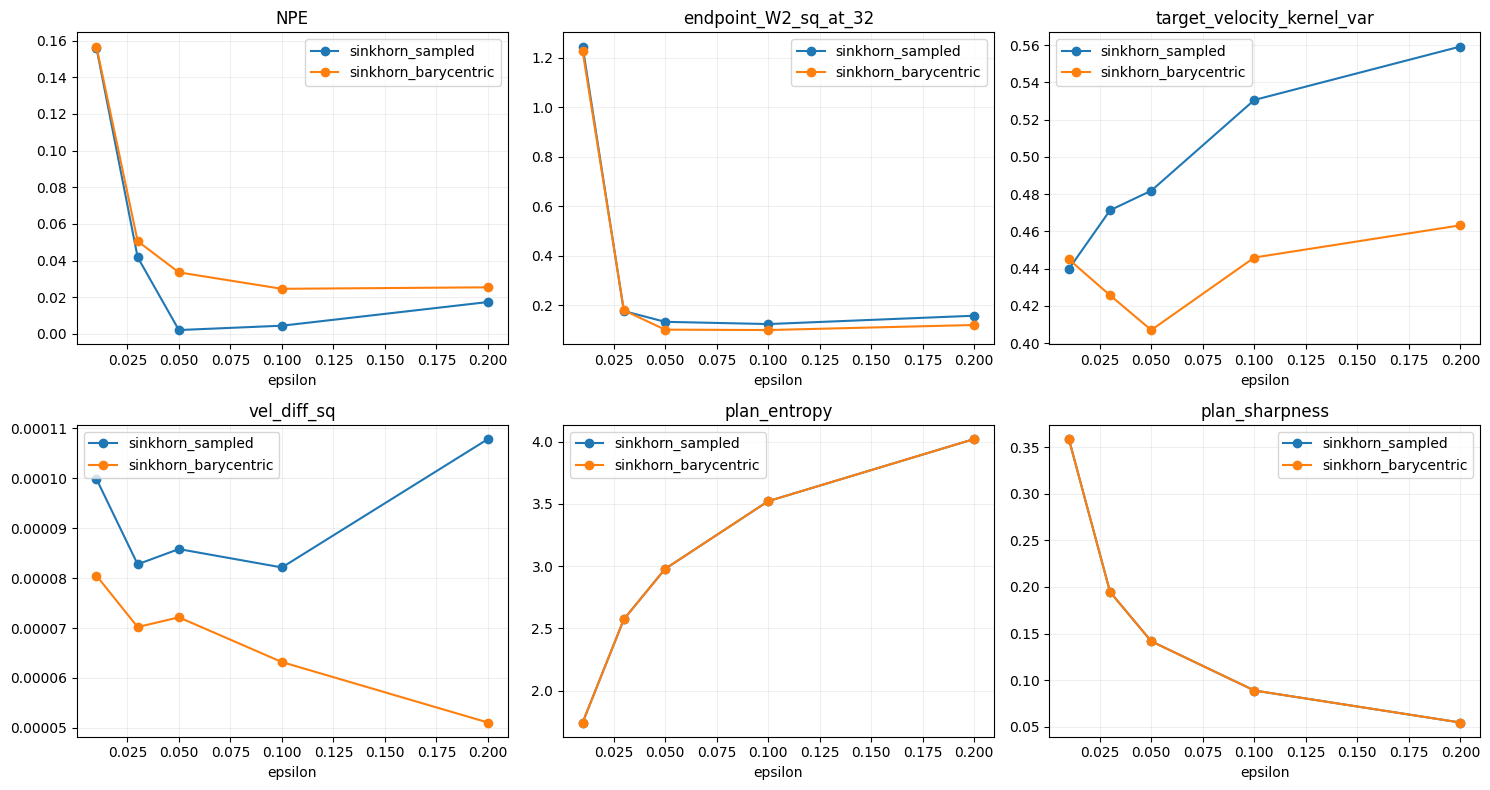

In [13]:
# =========================
# Epsilon-vs-metric plots (sampled vs barycentric)
# =========================
metrics_vs_eps = [
    "NPE",
    "endpoint_W2_sq_at_32",
    "target_velocity_kernel_var",
    "vel_diff_sq",
    "plan_entropy",
    "plan_sharpness",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, m in zip(axes.ravel(), metrics_vs_eps):
    for mode in ["sinkhorn_sampled", "sinkhorn_barycentric"]:
        d = summary_df[summary_df["mode"] == mode].sort_values("eps")
        ax.plot(d["eps"], d[m], marker="o", label=mode)
    ax.set_xlabel("epsilon")
    ax.set_title(m)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()


In [16]:
# =========================
# Mode coverage + mode-distance metrics for 8-Gaussians
# (across eps, separately for sampled vs barycentric)
# =========================

radius = 5.0
centers_8g = jnp.array([
    [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0],
    [1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)],
    [1.0 / jnp.sqrt(2), -1.0 / jnp.sqrt(2)],
    [-1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)],
    [-1.0 / jnp.sqrt(2), -1.0 / jnp.sqrt(2)],
]) * radius

def nearest_center_idx(x, centers):
    d2 = jnp.sum((x[:, None, :] - centers[None, :, :]) ** 2, axis=-1)  # (N,8)
    return jnp.argmin(d2, axis=1)

def occupancy_hist(x, centers, n_modes=8):
    idx = nearest_center_idx(x, centers)
    counts = np.bincount(np.asarray(idx), minlength=n_modes).astype(np.float64)
    probs = counts / max(counts.sum(), 1.0)
    return counts, probs

def mode_distance_metrics(x, centers):
    d2 = jnp.sum((x[:, None, :] - centers[None, :, :]) ** 2, axis=-1)
    min_d2 = jnp.min(d2, axis=1)
    return float(jnp.mean(min_d2)), float(jnp.quantile(min_d2, 0.9))

# fairness set
n_eval = min(x0.shape[0], x1.shape[0])
x0_eval = x0[:n_eval]
x1_eval = x1[:n_eval]

# target occupancy from true target samples
target_counts, target_probs = occupancy_hist(x1_eval, centers_8g, n_modes=8)

# lookup for (regime, eps) -> record
run_lookup = {(r["mode"], float(r["eps"])): r for r in run_records}

# settings
regimes = ["sinkhorn_sampled", "sinkhorn_barycentric"]
coverage_rollout_steps = 32
mode_presence_threshold = 0.02

mode_rows = []
eps_sorted = sorted([float(e) for e in eps_list])

for regime in regimes:
    for eps in eps_sorted:
        rec = run_lookup[(regime, eps)]
        x_gen = rollout_euler_final(rec["params"], x0_eval, steps=coverage_rollout_steps)

        gen_counts, gen_probs = occupancy_hist(x_gen, centers_8g, n_modes=8)

        mode_coverage = float(np.mean(gen_probs > mode_presence_threshold))
        occupancy_entropy = float(-(gen_probs * np.log(gen_probs + 1e-12)).sum())
        occupancy_entropy_norm = float(occupancy_entropy / np.log(8.0))
        occupancy_kl_target_to_gen = float(
            np.sum(target_probs * (np.log(target_probs + 1e-12) - np.log(gen_probs + 1e-12)))
        )

        mean_nearest_center_dist_sq, q90_nearest_center_dist_sq = mode_distance_metrics(x_gen, centers_8g)

        mode_rows.append({
            "eps": eps,
            "mode": regime,
            "mode_coverage": mode_coverage,
            "occupancy_entropy": occupancy_entropy,
            "occupancy_entropy_norm": occupancy_entropy_norm,
            "occupancy_kl_target_to_gen": occupancy_kl_target_to_gen,
            "mean_nearest_center_dist_sq": mean_nearest_center_dist_sq,
            "q90_nearest_center_dist_sq": q90_nearest_center_dist_sq,
            "gen_counts": gen_counts,
            "gen_probs": gen_probs,
        })

mode_df = pd.DataFrame(mode_rows).sort_values(["mode", "eps"]).reset_index(drop=True)
display(mode_df[[
    "eps", "mode", "mode_coverage", "occupancy_entropy",
    "occupancy_kl_target_to_gen", "mean_nearest_center_dist_sq"
]])


,eps,mode,mode_coverage,occupancy_entropy,occupancy_kl_target_to_gen,mean_nearest_center_dist_sq
0,0.01,sinkhorn_barycentric,1.0,2.065450,0.010938,0.463718
1,0.03,sinkhorn_barycentric,1.0,2.076704,0.000685,0.442832
2,0.05,sinkhorn_barycentric,1.0,2.077541,0.000867,0.430441
3,0.10,sinkhorn_barycentric,1.0,2.077521,0.000460,0.438172
4,0.20,sinkhorn_barycentric,1.0,2.077137,0.000194,0.439436
5,0.01,sinkhorn_sampled,1.0,2.065116,0.011876,0.461942
6,0.03,sinkhorn_sampled,1.0,2.077376,0.001170,0.468235
7,0.05,sinkhorn_sampled,1.0,2.076920,0.002375,0.494694
8,0.10,sinkhorn_sampled,1.0,2.077930,0.001052,0.470617
9,0.20,sinkhorn_sampled,1.0,2.077462,0.001154,0.474860


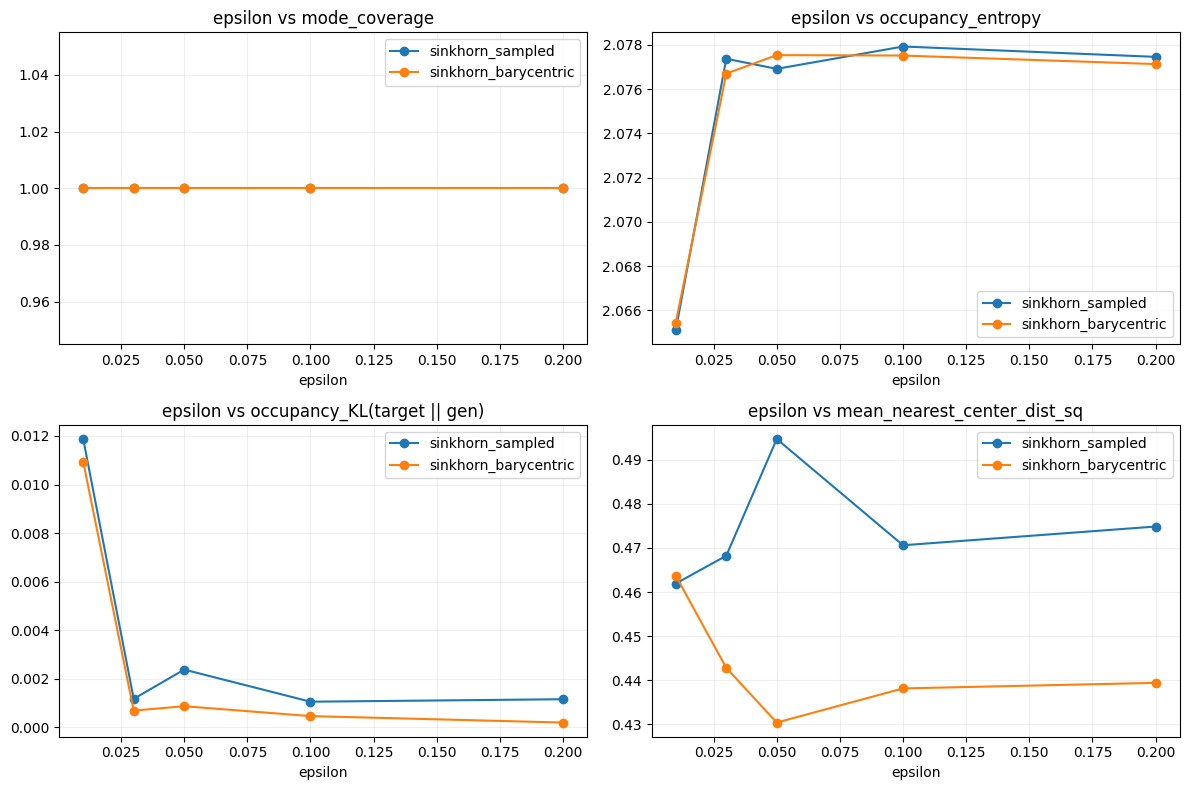

In [17]:
# =========================
# Plots: epsilon vs mode metrics (two curves)
# =========================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_metrics = [
    "mode_coverage",
    "occupancy_entropy",
    "occupancy_kl_target_to_gen",
    "mean_nearest_center_dist_sq",
]
titles = [
    "epsilon vs mode_coverage",
    "epsilon vs occupancy_entropy",
    "epsilon vs occupancy_KL(target || gen)",
    "epsilon vs mean_nearest_center_dist_sq",
]

for ax, m, t in zip(axes.ravel(), plot_metrics, titles):
    for regime in ["sinkhorn_sampled", "sinkhorn_barycentric"]:
        d = mode_df[mode_df["mode"] == regime].sort_values("eps")
        ax.plot(d["eps"], d[m], marker="o", label=regime)
    ax.set_title(t)
    ax.set_xlabel("epsilon")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()


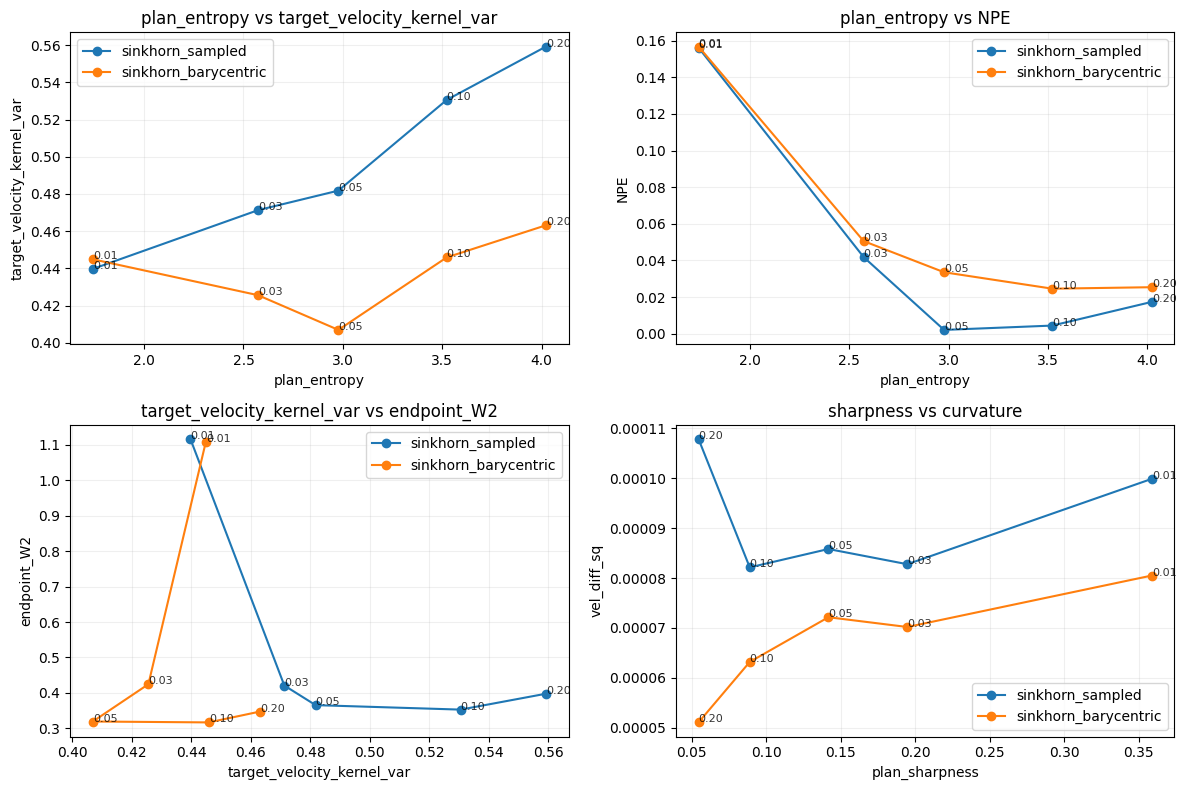

In [18]:
# =========================
# Pairwise comparison plots (barycentric vs sampled across eps)
# Uses summary_df from the multi-epsilon block
# =========================

# If endpoint_W2 (not squared) is preferred, derive it:
plot_df = summary_df.copy()
plot_df["endpoint_W2"] = np.sqrt(np.maximum(plot_df["endpoint_W2_sq_at_32"], 0.0))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

comparisons = [
    ("plan_entropy", "target_velocity_kernel_var", "plan_entropy vs target_velocity_kernel_var"),
    ("plan_entropy", "NPE", "plan_entropy vs NPE"),
    ("target_velocity_kernel_var", "endpoint_W2", "target_velocity_kernel_var vs endpoint_W2"),
    ("plan_sharpness", "vel_diff_sq", "sharpness vs curvature"),
]

for ax, (xcol, ycol, title) in zip(axes.ravel(), comparisons):
    for regime in ["sinkhorn_sampled", "sinkhorn_barycentric"]:
        d = plot_df[plot_df["mode"] == regime].sort_values("eps")
        ax.plot(d[xcol], d[ycol], marker="o", label=regime)

        # optional epsilon labels on points
        for _, r in d.iterrows():
            ax.annotate(f"{r['eps']:.2f}", (r[xcol], r[ycol]), fontsize=8, alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()


In [19]:
# =========================
# Multi-seed reruns + aggregation (mean/std)
# =========================

seeds = [0, 1, 2]
eps_list = [0.01, 0.03, 0.05, 0.1, 0.2]

n = 500
train_steps = 2000
widths = [3, 128, 128, 128, 2]
nfe_eval = 32  # endpoint quality budget

all_rows = []

for seed in seeds:
    key_seed = jax.random.PRNGKey(seed)
    key_seed, k0, k1, kinit, kpair_master, keval_master = jax.random.split(key_seed, 6)

    # data + init (seed-specific)
    x0 = sample_moons(k0, n)
    x1 = sample_8gaussians(k1, n)
    base_params = init_mlp_params(kinit, widths)
    t_schedule = make_t_schedule(seed=1000 + seed, steps=train_steps, n=n)

    n_eval = min(x0.shape[0], x1.shape[0])
    x0_eval = x0[:n_eval]
    x1_eval = x1[:n_eval]
    w2_data = empirical_w2_squared_hungarian(x0_eval, x1_eval)

    pair_keys = jax.random.split(kpair_master, len(eps_list))
    k_eval = keval_master

    for eps, kpair in zip(eps_list, pair_keys):
        P, _ = sinkhorn_coupling(x0, x1, epsilon=eps)

        row_sums = jnp.sum(P, axis=1, keepdims=True) + 1e-12
        W = P / row_sums
        plan_entropy = float(-jnp.mean(jnp.sum(W * jnp.log(W + 1e-12), axis=1)))
        plan_sharpness = float(jnp.mean(jnp.max(W, axis=1)))

        couplings = {
            "sinkhorn_sampled": sample_pairs_from_coupling(kpair, x0, x1, P),
            "sinkhorn_barycentric": sinkhorn_barycentric_pairing(x0, x1, P),
        }

        for mode, (xa, xb) in couplings.items():
            params_tr, losses = train_on_fixed_pairs(base_params, xa, xb, t_schedule)

            pe = path_energy(params_tr, x0_eval, steps=256)
            npe = abs(pe - w2_data) / (w2_data + 1e-12)

            x_gen = rollout_euler_final(params_tr, x0_eval, steps=nfe_eval)
            endpoint_w2_sq = empirical_w2_squared_hungarian(x_gen, x1_eval)
            endpoint_w2 = float(np.sqrt(max(endpoint_w2_sq, 0.0)))

            k_eval, kv = jax.random.split(k_eval)
            target_vel_var = float(
                velocity_variance_kernel(
                    xa, xb,
                    n_time_samples=8, sigma=0.6, key=kv,
                    n_query=1024, n_ref=2048,
                    include_time=True, time_scale=1.0
                )
            )

            curv = trajectory_curvature_metrics(params_tr, x0_eval, steps=128)

            all_rows.append({
                "seed": seed,
                "eps": float(eps),
                "mode": mode,
                "NPE": float(npe),
                "endpoint_W2_sq_at_32": float(endpoint_w2_sq),
                "endpoint_W2": endpoint_w2,
                "target_velocity_kernel_var": target_vel_var,
                "vel_diff_sq": float(curv["vel_diff_sq"]),
                "plan_entropy": plan_entropy,
                "plan_sharpness": plan_sharpness,
            })

all_df = pd.DataFrame(all_rows)
display(all_df.head())


,seed,eps,mode,NPE,endpoint_W2_sq_at_32,endpoint_W2,target_velocity_kernel_var,vel_diff_sq,plan_entropy,plan_sharpness
0,0,0.01,sinkhorn_sampled,0.152598,1.451939,1.204964,0.532974,0.000107,1.257614,0.489528
1,0,0.01,sinkhorn_barycentric,0.161691,1.481314,1.217092,0.470504,0.000093,1.257614,0.489528
2,0,0.03,sinkhorn_sampled,0.042972,0.230947,0.480569,0.533033,0.000086,1.964375,0.302559
3,0,0.03,sinkhorn_barycentric,0.041913,0.209458,0.457666,0.467050,0.000080,1.964375,0.302559
4,0,0.05,sinkhorn_sampled,0.031350,0.222441,0.471637,0.524591,0.000092,2.337658,0.230543


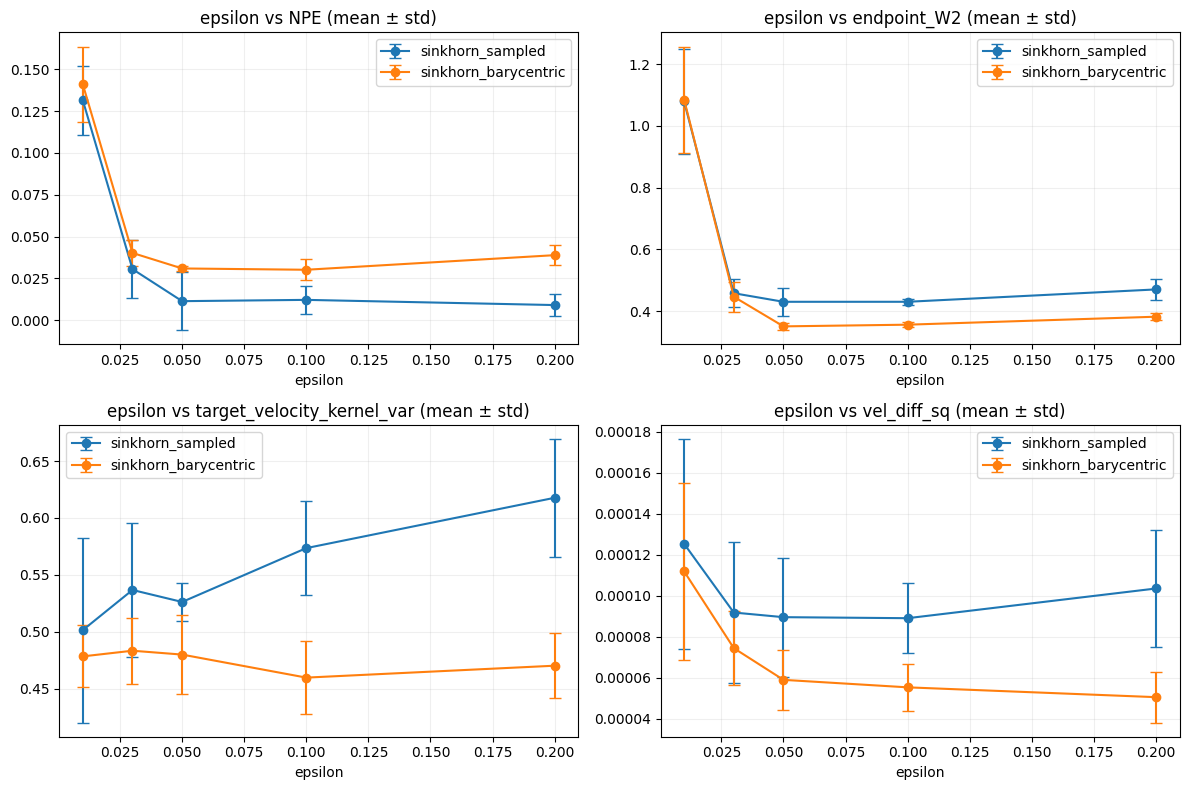

In [20]:
# =========================
# Aggregate mean ± std and plot error bars
# =========================

metrics = [
    "NPE",
    "endpoint_W2",                  # or endpoint_W2_sq_at_32 if you prefer squared
    "target_velocity_kernel_var",
    "vel_diff_sq",
]

agg = (
    all_df
    .groupby(["mode", "eps"])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

# flatten multi-index columns
agg.columns = [
    "_".join(c).strip("_") if isinstance(c, tuple) else c
    for c in agg.columns.values
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.ravel(), metrics):
    for mode in ["sinkhorn_sampled", "sinkhorn_barycentric"]:
        d = agg[agg["mode"] == mode].sort_values("eps")
        ax.errorbar(
            d["eps"],
            d[f"{m}_mean"],
            yerr=d[f"{m}_std"],
            marker="o",
            capsize=4,
            label=mode,
        )
    ax.set_title(f"epsilon vs {m} (mean ± std)")
    ax.set_xlabel("epsilon")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()


In [22]:
# =========================
# OT-to-independent interpolation (perturbed OT) 
# =========================


def make_hungarian_ot_plan(x0, x1):
    C = jnp.sum((x0[:, None, :] - x1[None, :, :]) ** 2, axis=-1)  # (N,N)
    row_ind, col_ind = linear_sum_assignment(np.asarray(C))
    N = x0.shape[0]
    pi_ot = np.zeros((N, N), dtype=np.float64)
    pi_ot[row_ind, col_ind] = 1.0 / N
    return jnp.array(pi_ot), C

def make_independent_plan(N):
    u = jnp.ones(N) / N
    return jnp.outer(u, u)

def interpolate_plans(pi_ot, pi_ind, alpha):
    return (1.0 - alpha) * pi_ot + alpha * pi_ind

def plan_descriptors(pi, x1, C):
    rowp = pi / (jnp.sum(pi, axis=1, keepdims=True) + 1e-12)
    H = -jnp.sum(rowp * jnp.log(rowp + 1e-12), axis=1)
    S = jnp.max(rowp, axis=1)
    xbar = rowp @ x1
    D = jnp.sum(rowp * jnp.sum((x1[None, :, :] - xbar[:, None, :]) ** 2, axis=-1), axis=1)
    return {
        "plan_entropy": float(jnp.mean(H)),
        "plan_sharpness": float(jnp.mean(S)),
        "plan_dispersion": float(jnp.mean(D)),
        "plan_transport_cost": float(jnp.sum(pi * C)),
    }

# -------------------------
# Config
# -------------------------
alpha_list = [0.0, 0.25, 0.5, 0.75, 1.0]
nfe_list_interp = [4, 8, 16, 32, 64]

# -------------------------
# Build OT and independent plans
# -------------------------
N = x0.shape[0]
assert x1.shape[0] == N, "x0 and x1 must have equal size"

pi_ot, C_ot = make_hungarian_ot_plan(x0, x1)
pi_ind = make_independent_plan(N)

# Marginal checks
u_np = np.ones(N) / N
for alpha in alpha_list:
    pi_alpha = interpolate_plans(pi_ot, pi_ind, alpha)
    mass_err = abs(float(jnp.sum(pi_alpha)) - 1.0)
    row_err = np.max(np.abs(np.asarray(jnp.sum(pi_alpha, axis=1)) - u_np))
    col_err = np.max(np.abs(np.asarray(jnp.sum(pi_alpha, axis=0)) - u_np))
    print(f"[alpha={alpha:.2f}] mass_err={mass_err:.3e}, row_err={row_err:.3e}, col_err={col_err:.3e}")

[alpha=0.00] mass_err=1.192e-07, row_err=9.499e-11, col_err=9.499e-11
[alpha=0.25] mass_err=5.484e-06, row_err=3.278e-10, col_err=3.278e-10
[alpha=0.50] mass_err=2.861e-06, row_err=7.935e-10, col_err=7.935e-10
[alpha=0.75] mass_err=8.345e-07, row_err=1.026e-09, col_err=1.259e-09
[alpha=1.00] mass_err=4.768e-06, row_err=3.278e-10, col_err=5.607e-10


In [23]:
# -------------------------
# Train all interpolation runs
# -------------------------
interp_run_records = []

key, k_interp_master = jax.random.split(key)
alpha_keys = jax.random.split(k_interp_master, len(alpha_list))

for alpha, ka in zip(alpha_list, alpha_keys):
    pi_alpha = interpolate_plans(pi_ot, pi_ind, alpha)
    desc = plan_descriptors(pi_alpha, x1, C_ot)

    # Reuse existing pairing utilities
    xa_s, xb_s = sample_pairs_from_coupling(ka, x0, x1, pi_alpha)
    xa_b, xb_b = sinkhorn_barycentric_pairing(x0, x1, pi_alpha)

    couplings_alpha = {
        "ot_ind_sampled": (xa_s, xb_s),
        "ot_ind_barycentric": (xa_b, xb_b),
    }

    for mode, (xa, xb) in couplings_alpha.items():
        params_tr, losses = train_on_fixed_pairs(base_params, xa, xb, t_schedule)

        interp_run_records.append({
            "mode": mode,
            "alpha": float(alpha),
            "name": f"{mode}_alpha={alpha:.2f}",
            "params": params_tr,
            "losses": np.asarray(losses),
            "xa": xa,
            "xb": xb,
            # no full pi_alpha storage
            "plan_entropy": desc["plan_entropy"],
            "plan_sharpness": desc["plan_sharpness"],
            "plan_dispersion": desc["plan_dispersion"],
            "plan_transport_cost": desc["plan_transport_cost"],
        })

print(f"interp_run_records: {len(interp_run_records)} runs")

interp_run_records: 10 runs


In [24]:
# -------------------------
# Evaluate runs
# -------------------------
n_eval = min(x0.shape[0], x1.shape[0])
x0_eval = x0[:n_eval]
x1_eval = x1[:n_eval]

# Recompute baseline (safer than reading from summary_df)
w2_data_sq = empirical_w2_squared_hungarian(x0_eval, x1_eval)

target_counts, target_probs = occupancy_hist(x1_eval, centers_8g, n_modes=8)

interp_summary_rows = []
interp_low_nfe_rows = []
interp_mode_rows = []

key, k_eval_master = jax.random.split(key)
eval_keys = jax.random.split(k_eval_master, len(interp_run_records))

for rec, kv in zip(interp_run_records, eval_keys):
    params = rec["params"]
    losses = rec["losses"]
    xa, xb = rec["xa"], rec["xb"]

    pe = path_energy(params, x0_eval, steps=256)
    npe = abs(pe - w2_data_sq) / (w2_data_sq + 1e-12)

    x_gen_32 = rollout_euler_final(params, x0_eval, steps=32)
    endpoint_w2_sq_32 = empirical_w2_squared_hungarian(x_gen_32, x1_eval)

    for nfe in nfe_list_interp:
        x_gen_nfe = rollout_euler_final(params, x0_eval, steps=nfe)
        w2_ep = empirical_w2_squared_hungarian(x_gen_nfe, x1_eval)
        interp_low_nfe_rows.append({
            "mode": rec["mode"],
            "alpha": rec["alpha"],
            "nfe": nfe,
            "endpoint_w2_sq": w2_ep,
        })

    target_vel_var = float(
        velocity_variance_kernel(
            xa, xb,
            n_time_samples=8,
            sigma=0.6,
            key=kv,
            n_query=1024,
            n_ref=2048,
            include_time=True,
            time_scale=1.0,
        )
    )

    curv = trajectory_curvature_metrics(params, x0_eval, steps=128)

    gen_counts, gen_probs = occupancy_hist(x_gen_32, centers_8g, n_modes=8)
    mode_coverage = float(np.mean(gen_probs > mode_presence_threshold))
    occupancy_entropy = float(-(gen_probs * np.log(gen_probs + 1e-12)).sum())
    occupancy_entropy_norm = float(occupancy_entropy / np.log(8.0))
    occupancy_kl_target_to_gen = float(
        np.sum(target_probs * (np.log(target_probs + 1e-12) - np.log(gen_probs + 1e-12)))
    )
    mean_nearest_center_dist_sq, q90_nearest_center_dist_sq = mode_distance_metrics(x_gen_32, centers_8g)

    interp_summary_rows.append({
        "mode": rec["mode"],
        "alpha": rec["alpha"],
        "PE": pe,
        "NPE": npe,
        "W2_data_sq": w2_data_sq,
        "endpoint_W2_sq_at_32": endpoint_w2_sq_32,
        "endpoint_W2_at_32": float(np.sqrt(max(endpoint_w2_sq_32, 0.0))),
        "loss_mean": float(np.mean(losses)),
        "loss_var": float(np.var(losses)),
        "target_velocity_kernel_var": target_vel_var,
        "vel_diff_sq": curv["vel_diff_sq"],
        "ang_dev": curv["ang_dev"],
        "plan_entropy": rec["plan_entropy"],
        "plan_sharpness": rec["plan_sharpness"],
        "plan_dispersion": rec["plan_dispersion"],
        "plan_transport_cost": rec["plan_transport_cost"],
    })

    interp_mode_rows.append({
        "mode": rec["mode"],
        "alpha": rec["alpha"],
        "mode_coverage": mode_coverage,
        "occupancy_entropy_norm": occupancy_entropy_norm,
        "occupancy_kl_target_to_gen": occupancy_kl_target_to_gen,
        "mean_nearest_center_dist_sq": mean_nearest_center_dist_sq,
        "q90_nearest_center_dist_sq": q90_nearest_center_dist_sq,
    })

interp_summary_df = pd.DataFrame(interp_summary_rows).sort_values(["mode", "alpha"]).reset_index(drop=True)
interp_low_nfe_df = pd.DataFrame(interp_low_nfe_rows).sort_values(["mode", "alpha", "nfe"]).reset_index(drop=True)
interp_mode_df = pd.DataFrame(interp_mode_rows).sort_values(["mode", "alpha"]).reset_index(drop=True)

display(interp_summary_df.head())
display(interp_low_nfe_df.head())
display(interp_mode_df.head())


,mode,alpha,PE,NPE,W2_data_sq,endpoint_W2_sq_at_32,endpoint_W2_at_32,loss_mean,loss_var,target_velocity_kernel_var,vel_diff_sq,ang_dev,plan_entropy,plan_sharpness,plan_dispersion,plan_transport_cost
0,ot_ind_barycentric,0.00,9.142561,0.011529,9.249199,0.108450,0.329318,0.319094,0.467172,0.504335,0.000055,0.000043,0.000000,1.0000,0.000000,9.249198
1,ot_ind_barycentric,0.25,4.671129,0.494969,9.249199,1.616260,1.271322,0.237043,0.149975,0.420137,0.000032,0.000006,2.111832,0.7505,10.988046,15.827251
2,ot_ind_barycentric,0.50,3.406975,0.631646,9.249199,6.317996,2.513562,0.190707,0.070810,0.396337,0.000031,0.000024,3.793236,0.5010,18.836645,22.405302
3,ot_ind_barycentric,0.75,5.391382,0.417097,9.249199,14.203680,3.768777,0.181724,0.109139,0.678112,0.000055,0.000004,5.214112,0.2515,23.545809,28.983353
4,ot_ind_barycentric,1.00,10.320625,0.115840,9.249199,24.971762,4.997175,0.404872,0.737335,3.639245,0.005778,0.000505,6.214605,0.0020,25.115538,35.561401


,mode,alpha,nfe,endpoint_w2_sq
0,ot_ind_barycentric,0.0,4,0.121332
1,ot_ind_barycentric,0.0,8,0.111730
2,ot_ind_barycentric,0.0,16,0.108963
3,ot_ind_barycentric,0.0,32,0.108450
4,ot_ind_barycentric,0.0,64,0.108641


,mode,alpha,mode_coverage,occupancy_entropy_norm,occupancy_kl_target_to_gen,mean_nearest_center_dist_sq,q90_nearest_center_dist_sq
0,ot_ind_barycentric,0.00,1.000,9.934890e-01,0.000269,0.513858,1.162979
1,ot_ind_barycentric,0.25,1.000,9.932541e-01,0.000431,1.871033,3.313082
2,ot_ind_barycentric,0.50,1.000,9.916644e-01,0.000997,6.397340,8.238012
3,ot_ind_barycentric,0.75,1.000,9.902403e-01,0.005511,14.080611,16.172869
4,ot_ind_barycentric,1.00,0.125,-4.809411e-13,21.142600,21.705778,21.840368


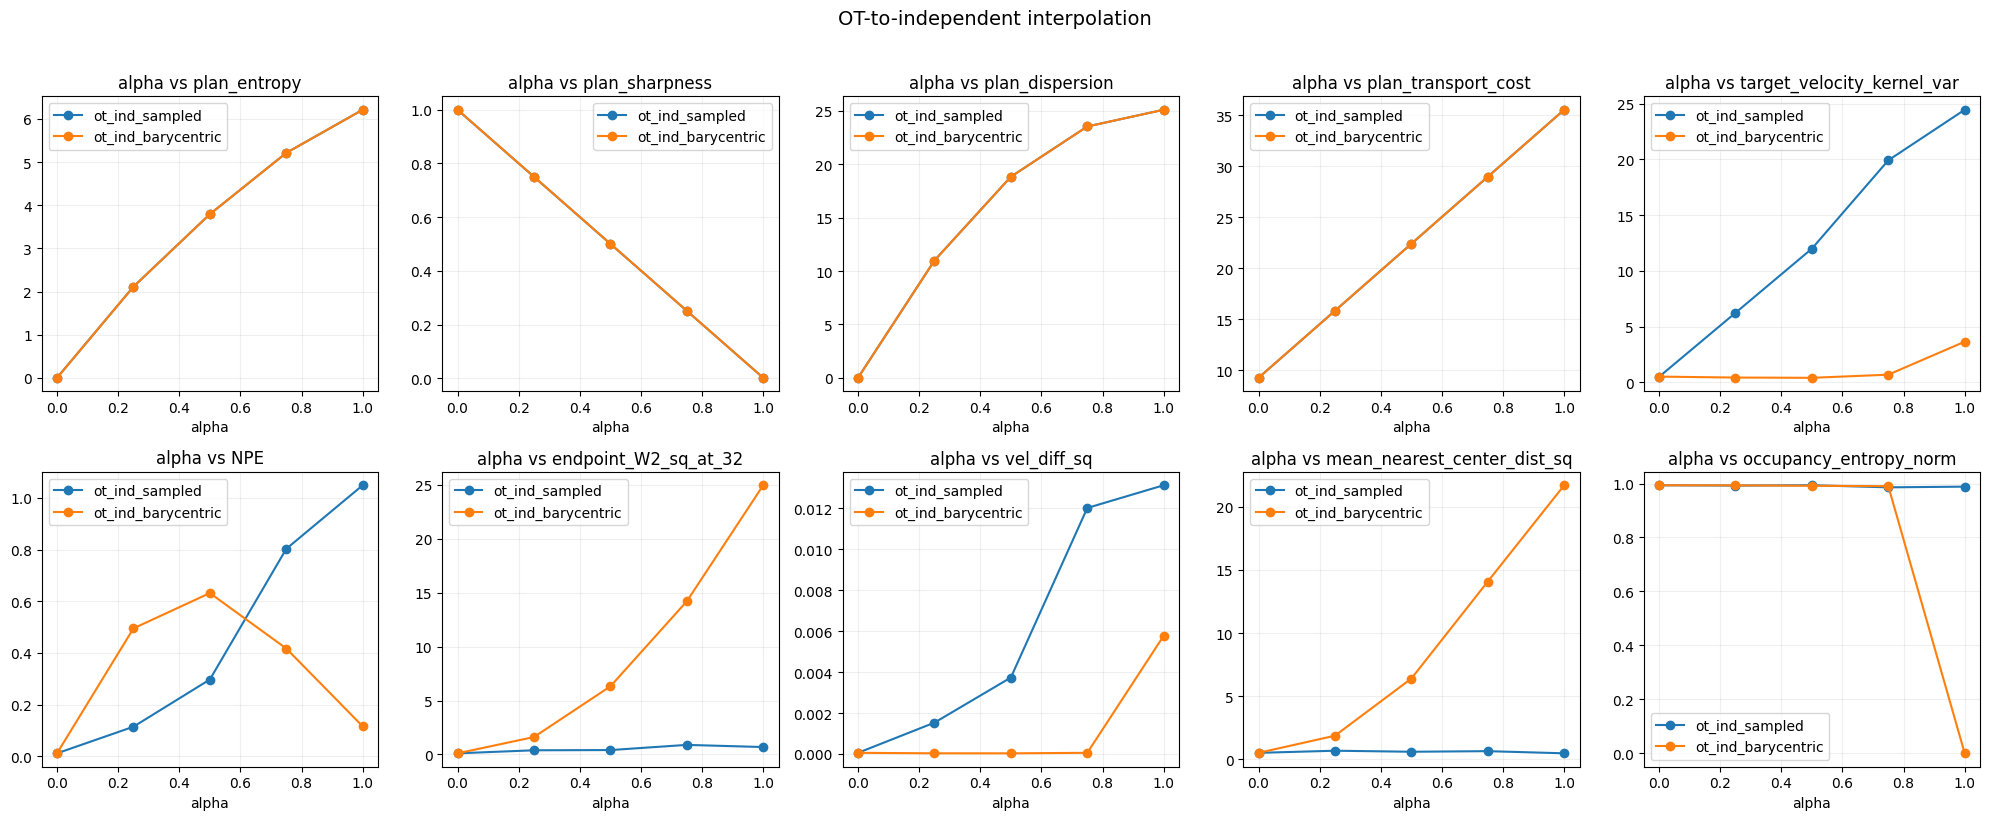

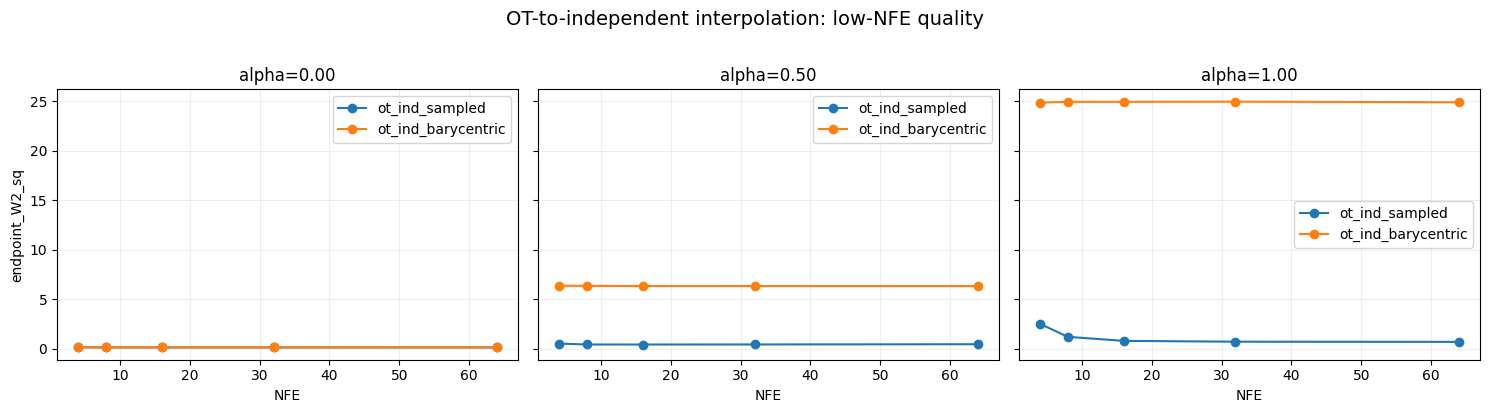

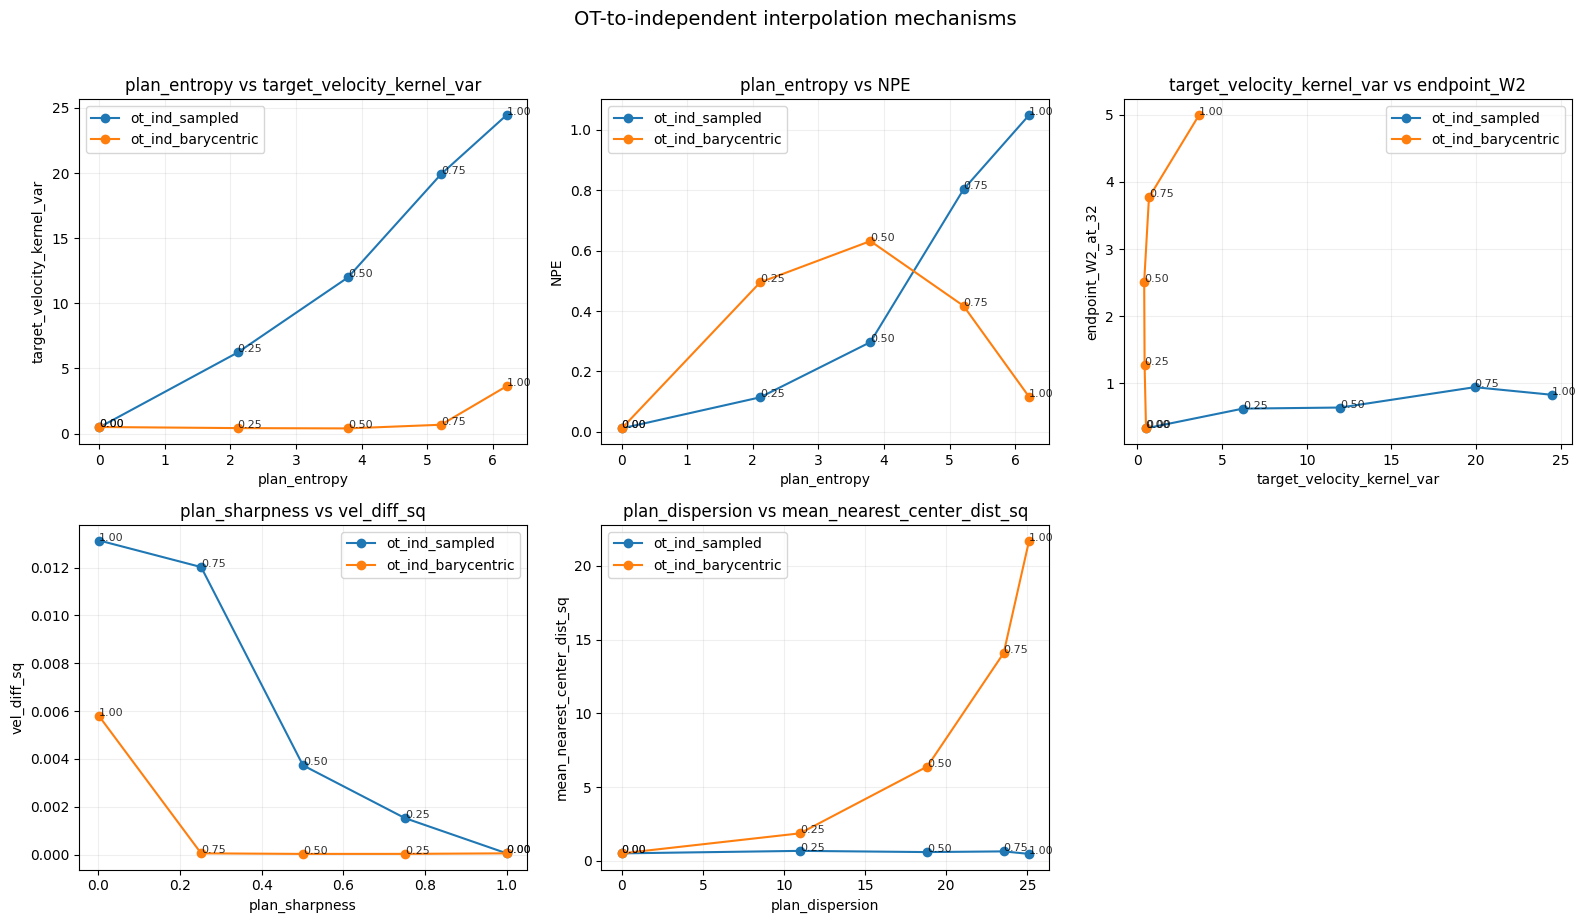

In [25]:
# -------------------------
# Plots A: alpha curves (sampled vs barycentric)
# -------------------------
interp_plot_df = interp_summary_df.merge(interp_mode_df, on=["mode", "alpha"], how="left")
interp_plot_df = interp_plot_df.sort_values(["mode", "alpha"]).reset_index(drop=True)

metrics_alpha = [
    "plan_entropy",
    "plan_sharpness",
    "plan_dispersion",
    "plan_transport_cost",
    "target_velocity_kernel_var",
    "NPE",
    "endpoint_W2_sq_at_32",
    "vel_diff_sq",
    "mean_nearest_center_dist_sq",
    "occupancy_entropy_norm",
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, m in zip(axes.ravel(), metrics_alpha):
    for regime in ["ot_ind_sampled", "ot_ind_barycentric"]:
        d = interp_plot_df[interp_plot_df["mode"] == regime].sort_values("alpha")
        ax.plot(d["alpha"], d[m], marker="o", label=regime)
    ax.set_title(f"alpha vs {m}")
    ax.set_xlabel("alpha")
    ax.grid(alpha=0.2)
    ax.legend()

plt.suptitle("OT-to-independent interpolation", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------
# Plots B: low-NFE for alpha = 0.0, 0.5, 1.0
# -------------------------
alphas_show = [0.0, 0.5, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, a in zip(axes, alphas_show):
    for regime in ["ot_ind_sampled", "ot_ind_barycentric"]:
        d = interp_low_nfe_df[
            (interp_low_nfe_df["mode"] == regime) &
            (np.isclose(interp_low_nfe_df["alpha"], a))
        ].sort_values("nfe")
        ax.plot(d["nfe"], d["endpoint_w2_sq"], marker="o", label=regime)
    ax.set_title(f"alpha={a:.2f}")
    ax.set_xlabel("NFE")
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel("endpoint_W2_sq")
plt.suptitle("OT-to-independent interpolation: low-NFE quality", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------
# Plots C: pairwise mechanism plots with alpha labels
# -------------------------
pairs = [
    ("plan_entropy", "target_velocity_kernel_var", "plan_entropy vs target_velocity_kernel_var"),
    ("plan_entropy", "NPE", "plan_entropy vs NPE"),
    ("target_velocity_kernel_var", "endpoint_W2_at_32", "target_velocity_kernel_var vs endpoint_W2"),
    ("plan_sharpness", "vel_diff_sq", "plan_sharpness vs vel_diff_sq"),
    ("plan_dispersion", "mean_nearest_center_dist_sq", "plan_dispersion vs mean_nearest_center_dist_sq"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.ravel()

for i, (xcol, ycol, title) in enumerate(pairs):
    ax = axes_flat[i]
    for regime in ["ot_ind_sampled", "ot_ind_barycentric"]:
        d = interp_plot_df[interp_plot_df["mode"] == regime].sort_values("alpha")
        ax.plot(d[xcol], d[ycol], marker="o", label=regime)
        for _, r in d.iterrows():
            ax.annotate(f"{r['alpha']:.2f}", (r[xcol], r[ycol]), fontsize=8, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(alpha=0.2)
    ax.legend()

axes_flat[-1].axis("off")
plt.suptitle("OT-to-independent interpolation mechanisms", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


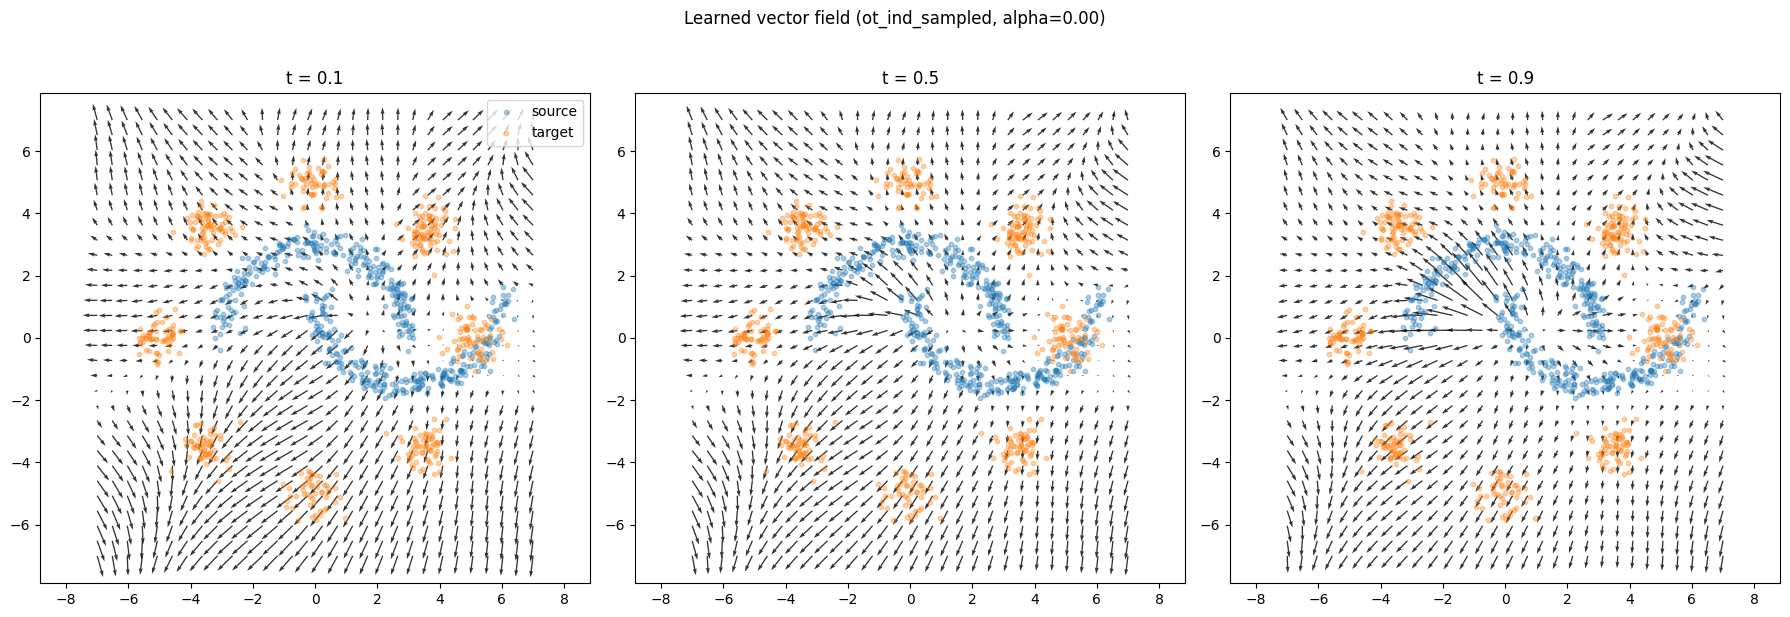

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


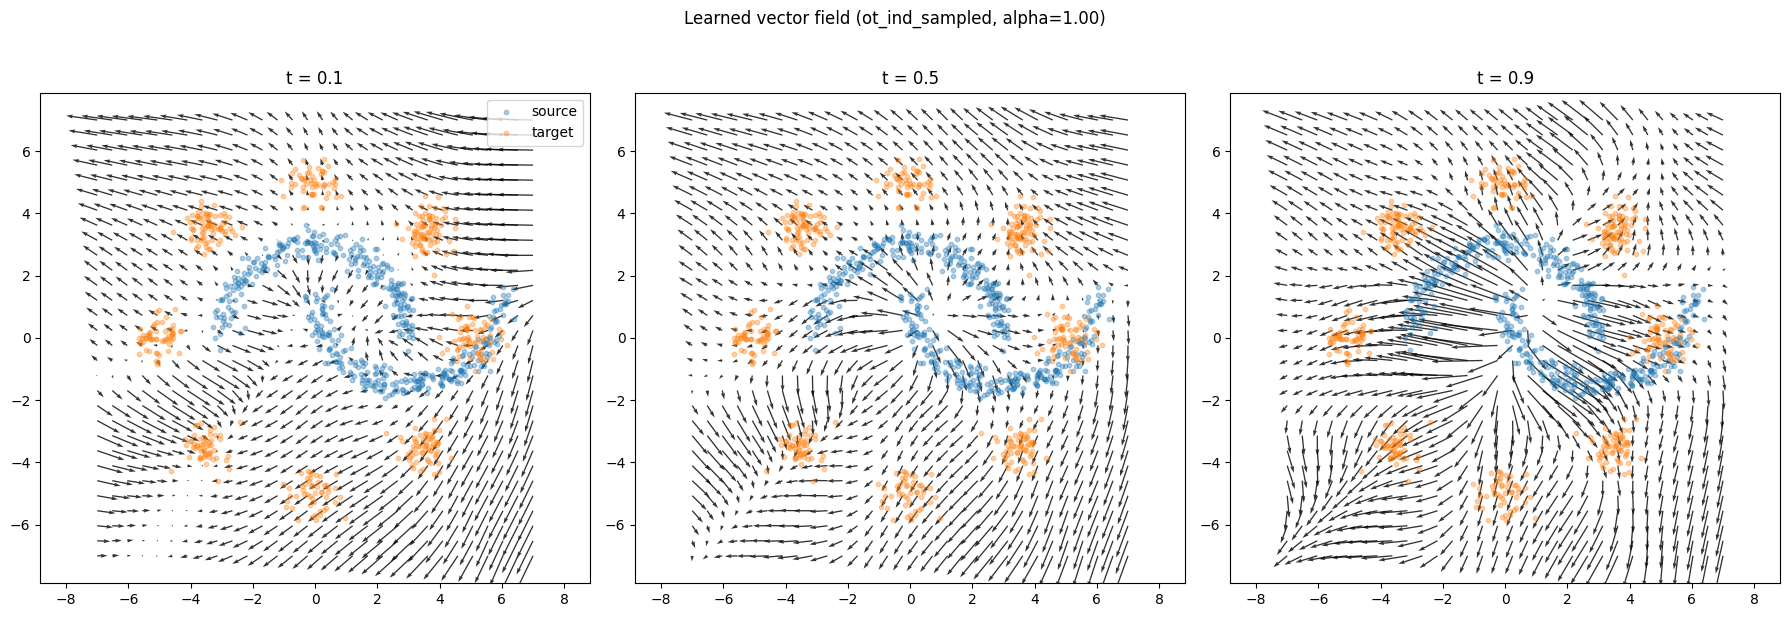

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


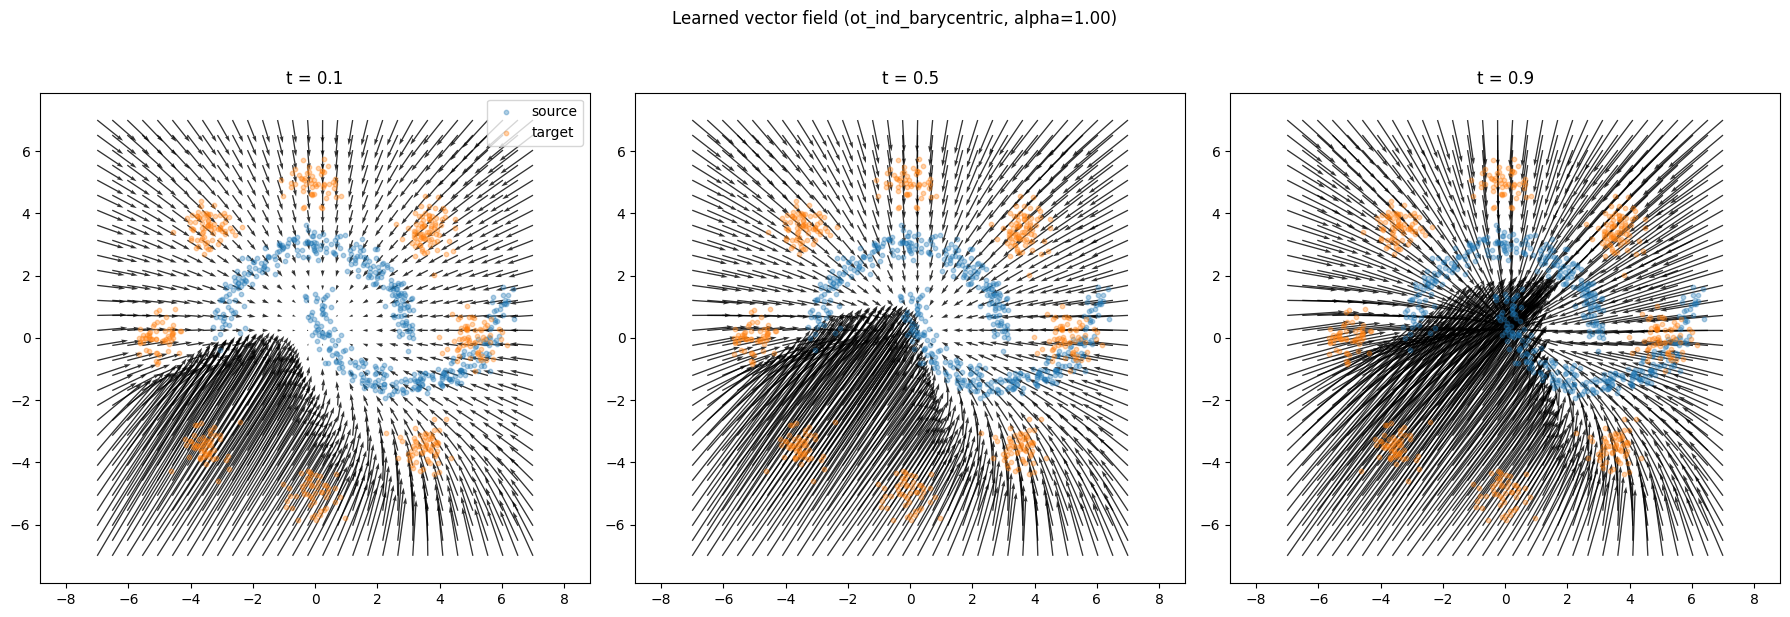

In [26]:
# =========================
# Vector fields for selected OT-to-independent runs
# at t = 0.1, 0.5, 0.9
# (same style as existing notebook vector-field cell)
# =========================

selected_cases = [
    ("ot_ind_sampled", 0.0),
    ("ot_ind_sampled", 1.0),
    ("ot_ind_barycentric", 1.0),
]
t_values = [0.1, 0.5, 0.9]

for mode, alpha in selected_cases:
    rec = [r for r in interp_run_records if r["mode"] == mode and np.isclose(r["alpha"], alpha)][0]
    params_sel = rec["params"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, tval in zip(axes, t_values):
        grid_x = jnp.linspace(-7, 7, 30)
        grid_y = jnp.linspace(-7, 7, 30)
        xx, yy = jnp.meshgrid(grid_x, grid_y)
        points = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

        t = tval * jnp.ones((points.shape[0], 1))
        v = vf_apply(params_sel, points, t)

        u = np.array(v[:, 0]).reshape(xx.shape)
        w = np.array(v[:, 1]).reshape(yy.shape)

        ax.quiver(np.array(xx), np.array(yy), u, w, angles="xy", scale_units="xy", scale=10, alpha=0.8)
        ax.scatter(np.array(x0[:, 0]), np.array(x0[:, 1]), s=10, alpha=0.35, label="source")
        ax.scatter(np.array(x1[:, 0]), np.array(x1[:, 1]), s=10, alpha=0.35, label="target")
        ax.set_title(f"t = {tval:.1f}")
        ax.axis("equal")
        ax.set_xlim(-7, 7)
        ax.set_ylim(-7, 7)

    axes[0].legend()
    fig.suptitle(f"Learned vector field ({mode}, alpha={alpha:.2f})", y=1.02)
    plt.tight_layout()
    plt.show()
